In [150]:
import os
import cv2
import argparse
import numpy as np
import time
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import skew, kurtosis, spearmanr, kendalltau, wasserstein_distance
from skimage.metrics import structural_similarity as ssim
from math import log2
import seaborn as sns
from mtcnn import MTCNN
from face_tool import get_face_image
from ImageConstruct import CImageUtils,CImageAlpha,CImageMFS
from DatasetConstruct import CDatasetConstruct
from ImageSimilarity import CImageSimilarity
from ImageDecompose import CImageDecompose
np.set_printoptions(suppress=True, precision=8)

In [151]:
detector = MTCNN(device="cpu")

In [152]:
#不同的real/fake子图的相似度
def compaire_similar(real_list,fake_list):        
    all_data = []
    for real,fake in tqdm(zip(real_list,fake_list),total=len(real_list)):
        if np.sum(real) !=0 :
            metrics = CImageSimilarity(bins=256).compare(real, fake, auto_normalize=True)
            tmp = metrics['score']
            tmp["detail"] = metrics
            all_data.append(tmp)
    
    df_score = pd.DataFrame(all_data)
    df_score['top_n'] = df_score.index
    ys = ["Overall", "Histogram", "Statistical", "Information"]
    if len(real_list) > 1:
        CImageSimilarity.display_plots(df_score, x="top_n", ys=ys)
    else:
        display(df_score)
    return df_score
    
def show_compare(df_score,real_list,fake_list):
    #相似度score的拐点
    idx = CImageSimilarity.find_peaks(-df_score['Overall'],prominence=0.0001) 
    if len(idx) == 0:
        idx = int(np.argmin(df_score['Overall']))
        idx = [ idx ]
    print("key fade points:",idx)
    new_list = [real_list[i] for i in idx]
    CImageUtils.display(new_list)
    new_list = [fake_list[i] for i in idx]
    CImageUtils.display(new_list)

# 读取原始数据

In [153]:
real_mean = CImageUtils.read_image("./images/real-mean.exr")
real_std = CImageUtils.read_image("./images/real-std.exr")
real_mean = cv2.cvtColor(real_mean, cv2.COLOR_BGR2RGB)
real_std = cv2.cvtColor(real_std, cv2.COLOR_BGR2RGB)
fake_mean = CImageUtils.read_image("./images/fake-mean.exr")
fake_std = CImageUtils.read_image("./images/fake-std.exr")
fake_mean = cv2.cvtColor(fake_mean, cv2.COLOR_BGR2RGB)
fake_std = cv2.cvtColor(fake_std, cv2.COLOR_BGR2RGB)

real_mean = get_face_image(detector,"./images/real-mean.exr")
fake_mean = get_face_image(detector,"./images/fake-mean.exr")

real_mean = CImageUtils.resize(real_mean)
fake_mean = CImageUtils.resize(fake_mean)

real_mean_list = CImageDecompose(real_mean).get_svd_auto(count=128)
fake_mean_list = CImageDecompose(fake_mean).get_svd_auto(count=128)
real_std_list = CImageDecompose(real_std).get_svd_auto(count=128)
fake_std_list = CImageDecompose(fake_std).get_svd_auto(count=128)

# 选取合适的fade的参数

100%|██████████| 128/128 [00:09<00:00, 14.13it/s]


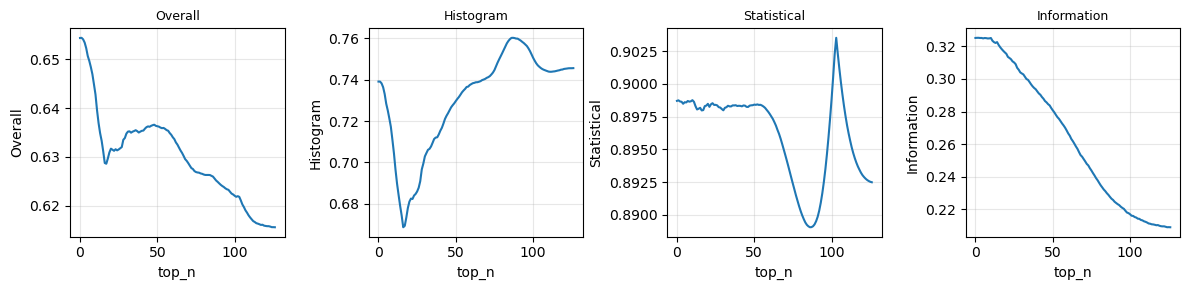

100%|██████████| 128/128 [00:11<00:00, 11.52it/s]


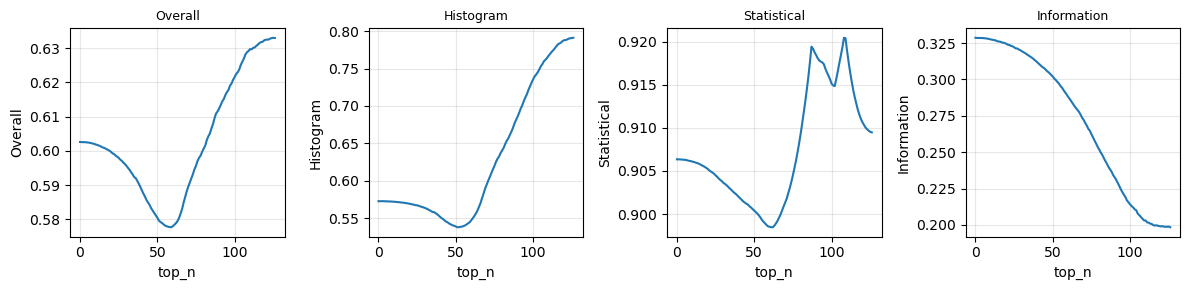

In [154]:
df_score = compaire_similar(real_mean_list,fake_mean_list)
df_score = compaire_similar(real_std_list,fake_std_list)

key fade points: [59]


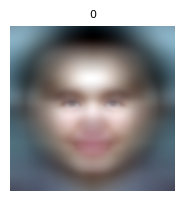

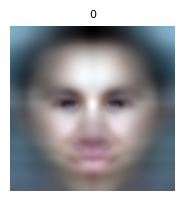

In [155]:
show_compare(df_score,real_svd_mean,fake_svd_mean)

# Local alpha

100%|██████████| 128/128 [00:09<00:00, 12.94it/s]


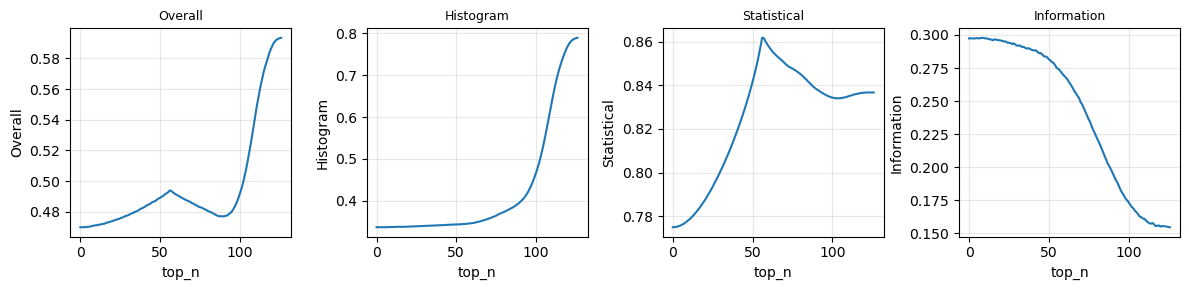

100%|██████████| 128/128 [00:10<00:00, 12.22it/s]


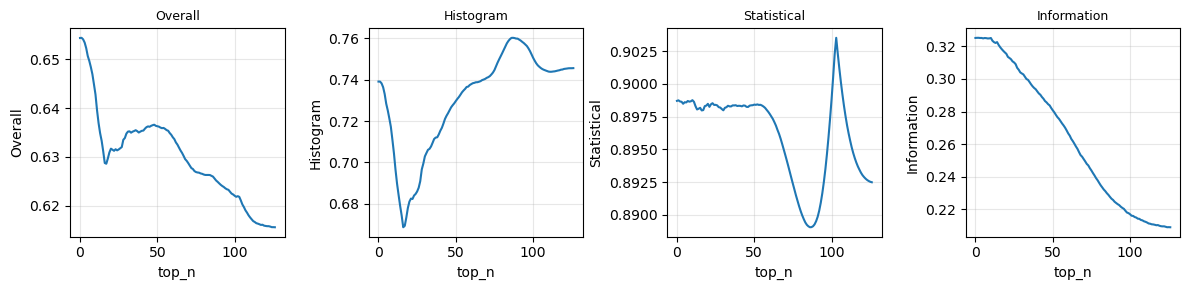

100%|██████████| 128/128 [00:10<00:00, 11.95it/s]


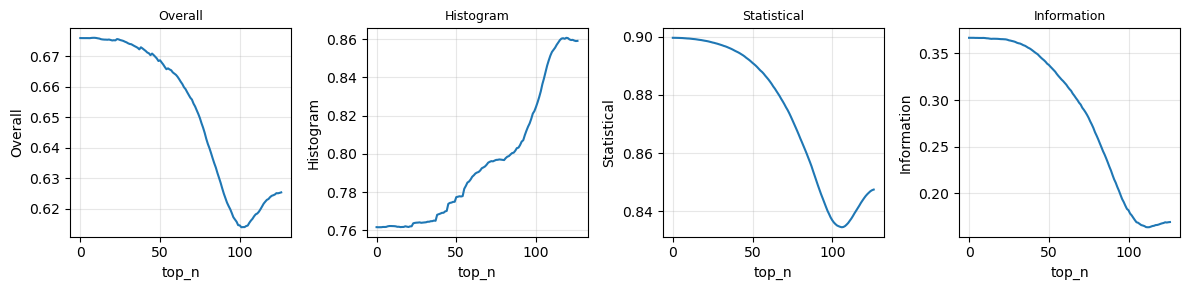

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


key fade points: [ 20  37  44  49  54 101]


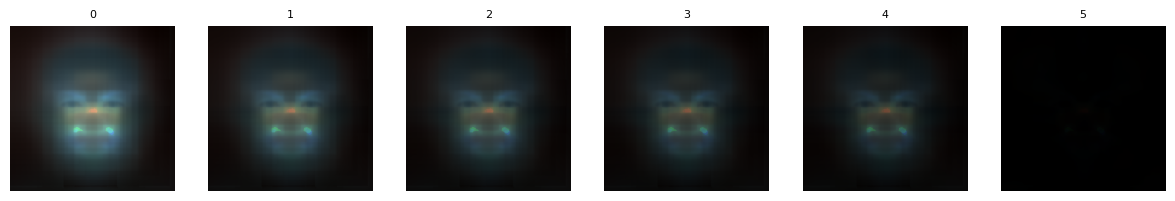

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


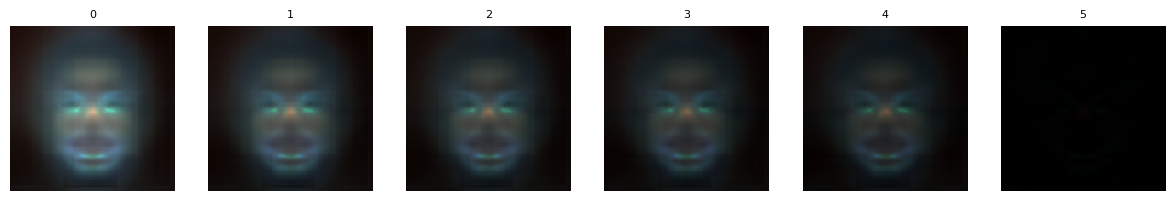

In [156]:
real_alpha = CImageAlpha(real_mean).get_raw_alpha()
fake_alpha = CImageAlpha(fake_mean).get_raw_alpha()
real_alpha_list = CImageDecompose(real_alpha).get_svd_auto(count=128)
fake_alpha_list = CImageDecompose(fake_alpha).get_svd_auto(count=128)
df_score = compaire_similar(real_alpha_list,fake_alpha_list)
df_score = compaire_similar(real_mean_list,fake_mean_list)

real_alpha = CImageAlpha(real_std).get_raw_alpha()
fake_alpha = CImageAlpha(fake_std).get_raw_alpha()
real_alpha_list = CImageDecompose(real_alpha).get_svd_auto(count=128)
fake_alpha_list = CImageDecompose(fake_alpha).get_svd_auto(count=128)
df_score = compaire_similar(real_alpha_list,fake_alpha_list)
show_compare(df_score,real_alpha_list,fake_alpha_list)

100%|██████████| 128/128 [00:10<00:00, 11.77it/s]


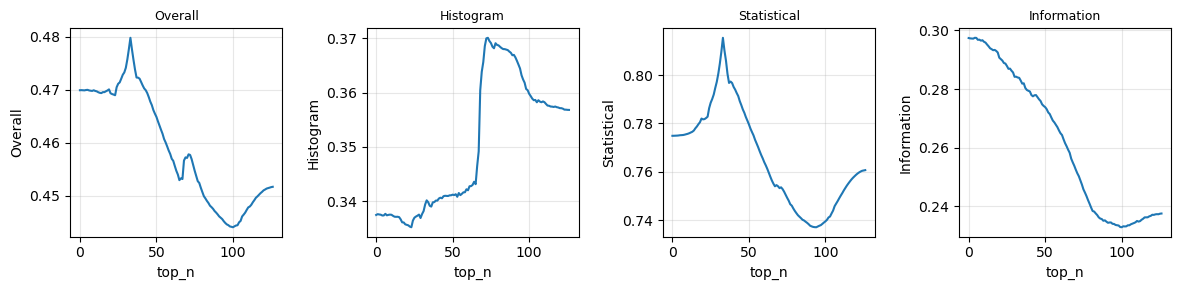

100%|██████████| 128/128 [00:10<00:00, 11.91it/s]


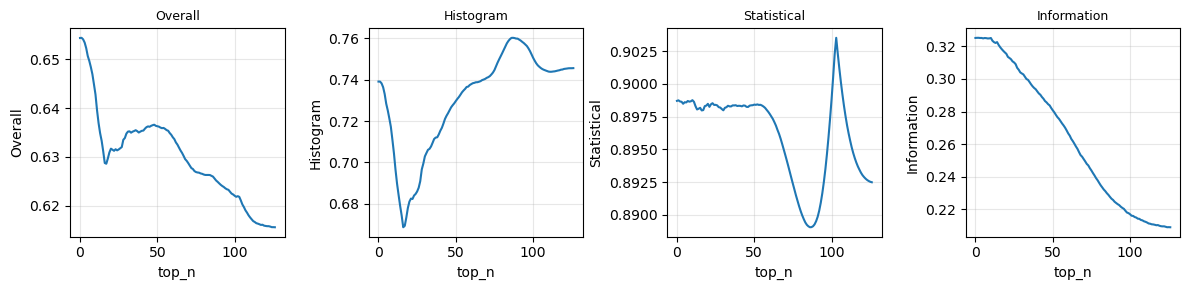

100%|██████████| 128/128 [00:10<00:00, 12.47it/s]


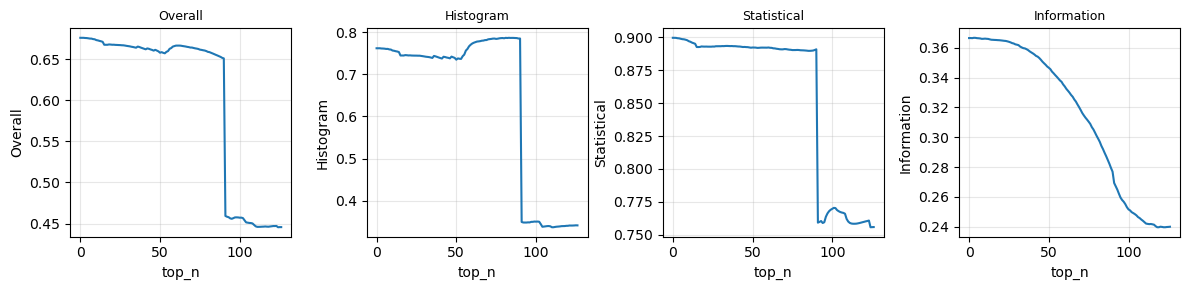

100%|██████████| 128/128 [00:10<00:00, 12.04it/s]


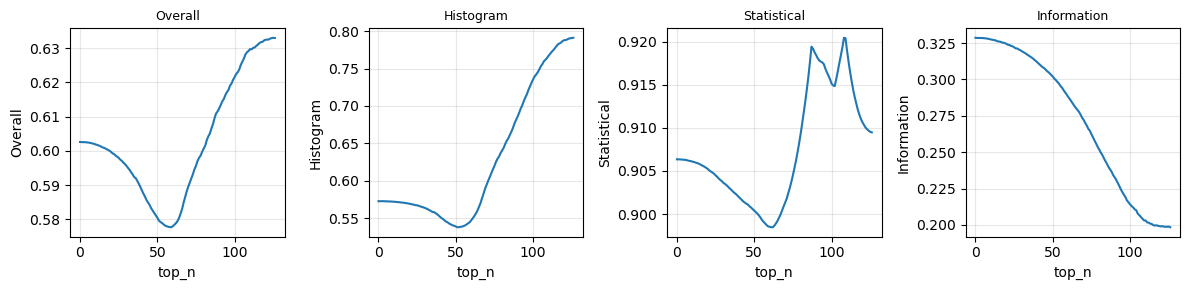

key fade points: [59]


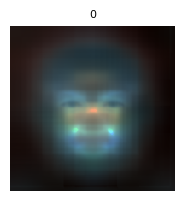

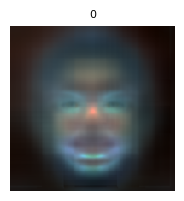

In [157]:
real_list = []
fake_list = []
for real,fake in tqdm(zip(real_mean_list,fake_mean_list),total=len(real_mean_list)):
    img1 = CImageAlpha(real).get_raw_alpha()
    img2 = CImageAlpha(fake).get_raw_alpha()
    real_list.append(img1)
    fake_list.append(img2)

df_score = compaire_similar(real_list,fake_list)
df_score = compaire_similar(real_mean_list,fake_mean_list)

real_list = []
fake_list = []
for real,fake in tqdm(zip(real_std_list,fake_std_list),total=len(real_std_list)):
    img1 = CImageAlpha(real).get_raw_alpha()
    img2 = CImageAlpha(fake).get_raw_alpha()
    real_list.append(img1)
    fake_list.append(img2)

df_score = compaire_similar(real_list,fake_list)
df_score = compaire_similar(real_std_list,fake_std_list)
show_compare(df_score,real_list,fake_list)
#show_compare(df_score,real_list,fake_list)
#CImageUtils.display([real_alpha_mean,real_alpha_std])
#CImageUtils.display([fake_alpha_mean,fake_alpha_std])

# Gray & Bin & alpha

100%|██████████| 128/128 [00:09<00:00, 13.22it/s]


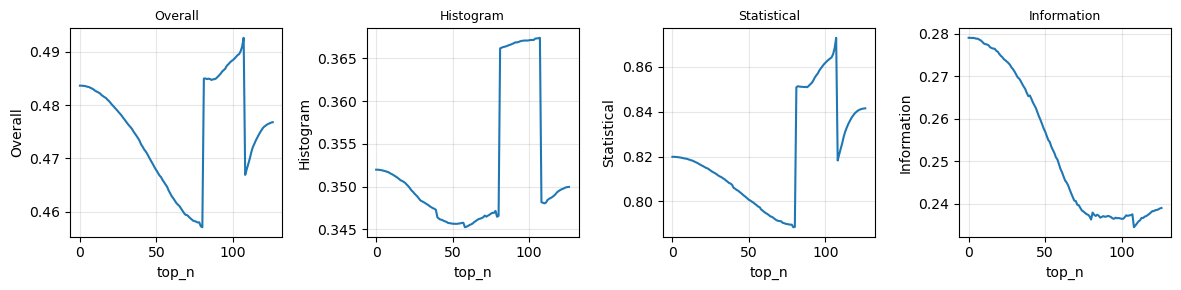

100%|██████████| 128/128 [00:10<00:00, 11.77it/s]


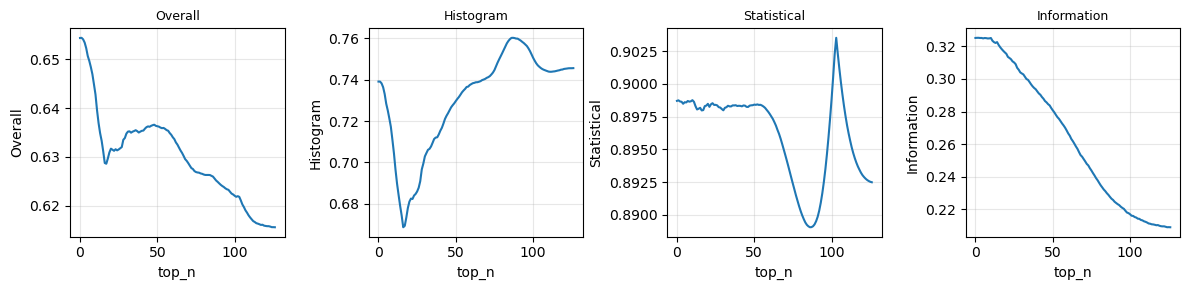

100%|██████████| 128/128 [00:11<00:00, 11.46it/s]


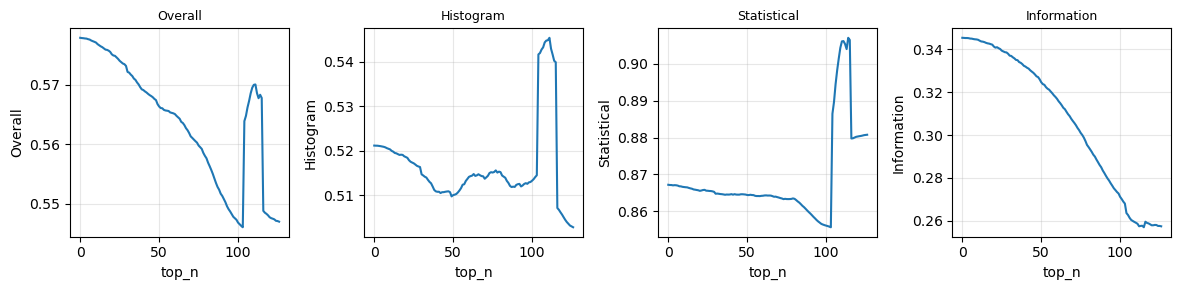

100%|██████████| 128/128 [00:10<00:00, 12.20it/s]


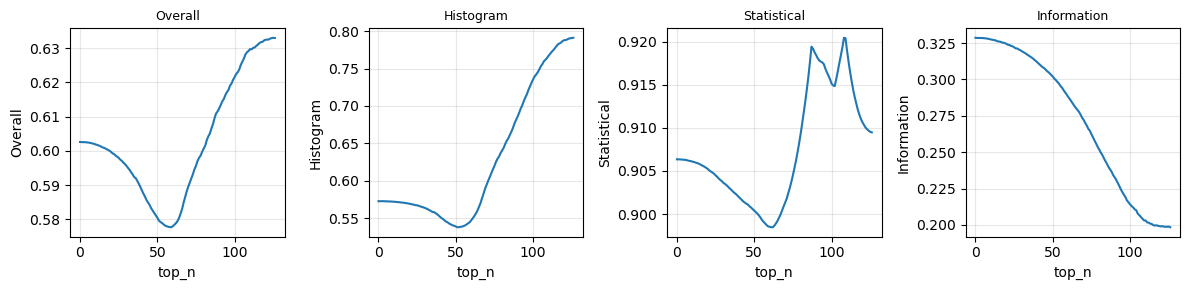

In [143]:
real_gray = CImageAlpha(real_mean_list[51]).get_gray_alpha(count=128)
fake_gray = CImageAlpha(fake_mean_list[51]).get_gray_alpha(count=128)
df_score = compaire_similar(real_gray,fake_gray)
df_score = compaire_similar(real_mean_list,fake_mean_list)

real_gray = CImageAlpha(real_std_list[51]).get_gray_alpha(count=128)
fake_gray = CImageAlpha(fake_std_list[51]).get_gray_alpha(count=128)
df_score = compaire_similar(real_gray,fake_gray)
df_score = compaire_similar(real_std_list,fake_std_list)

100%|██████████| 128/128 [00:07<00:00, 16.11it/s]


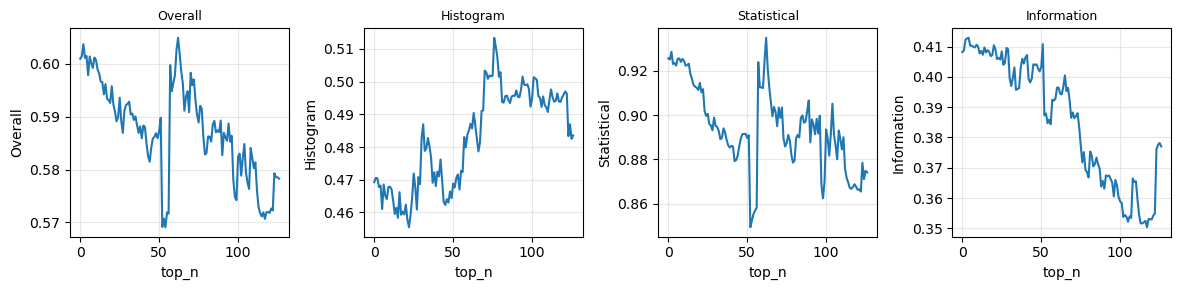

100%|██████████| 128/128 [00:10<00:00, 12.32it/s]


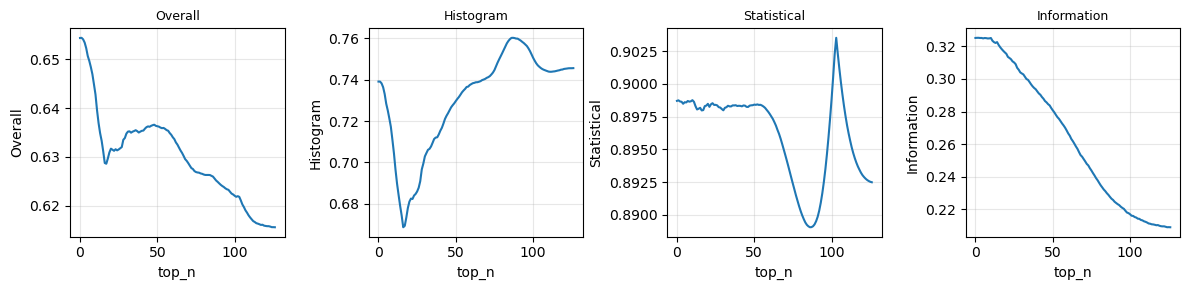

100%|██████████| 128/128 [00:07<00:00, 16.42it/s]


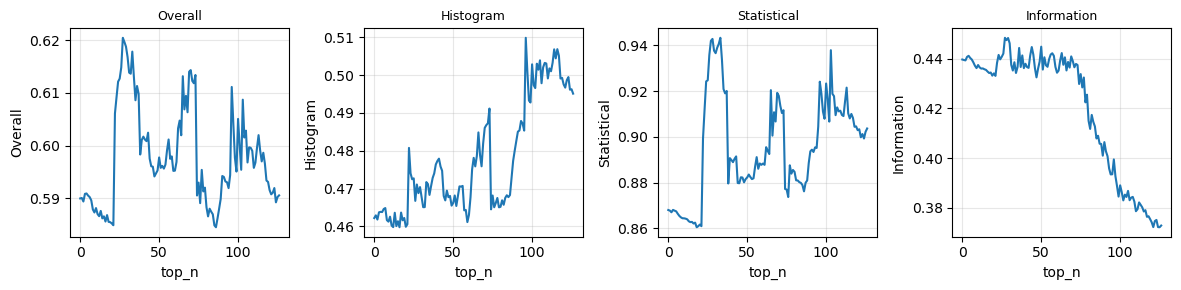

100%|██████████| 128/128 [00:12<00:00, 10.30it/s]


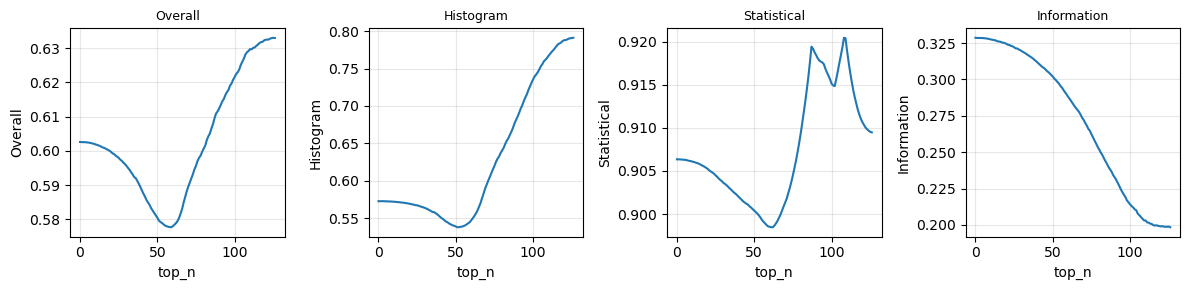

In [144]:
real_bin = CImageAlpha(real_mean_list[51]).get_bin_alpha(count=128)
fake_bin = CImageAlpha(fake_mean_list[51]).get_bin_alpha(count=128)
df_score = compaire_similar(real_bin,fake_bin)
df_score = compaire_similar(real_mean_list,fake_mean_list)

real_bin = CImageAlpha(real_std_list[51]).get_bin_alpha(count=128)
fake_bin = CImageAlpha(fake_std_list[51]).get_bin_alpha(count=128)
df_score = compaire_similar(real_bin,fake_bin)
df_score = compaire_similar(real_std_list,fake_std_list)

100%|██████████| 128/128 [00:11<00:00, 11.45it/s]


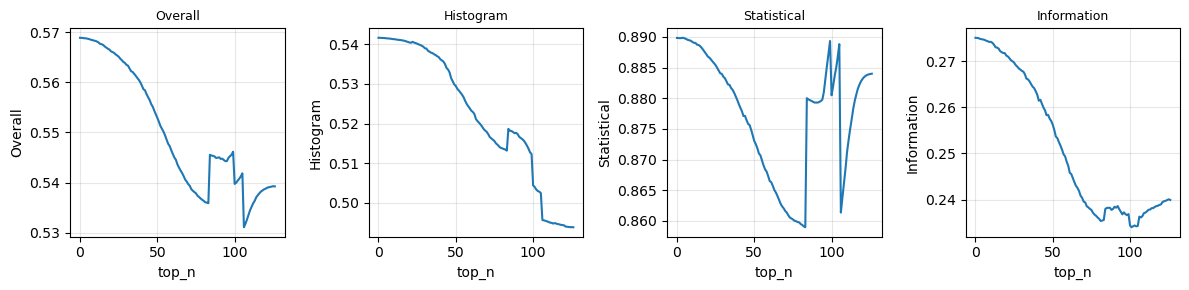

100%|██████████| 128/128 [00:12<00:00, 10.45it/s]


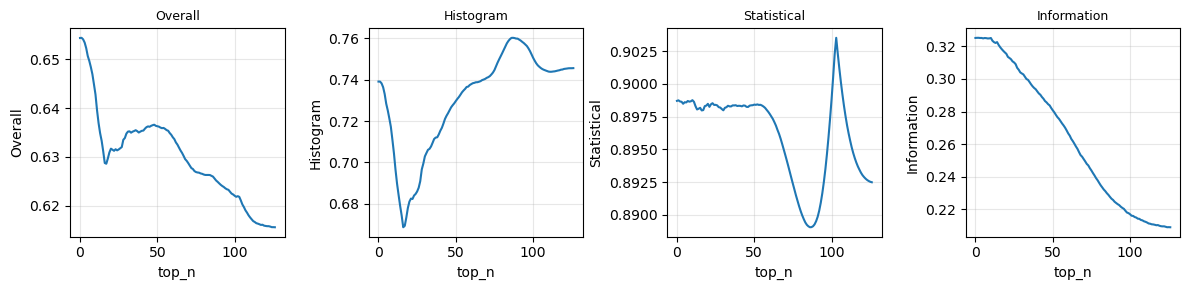

100%|██████████| 128/128 [00:11<00:00, 11.41it/s]


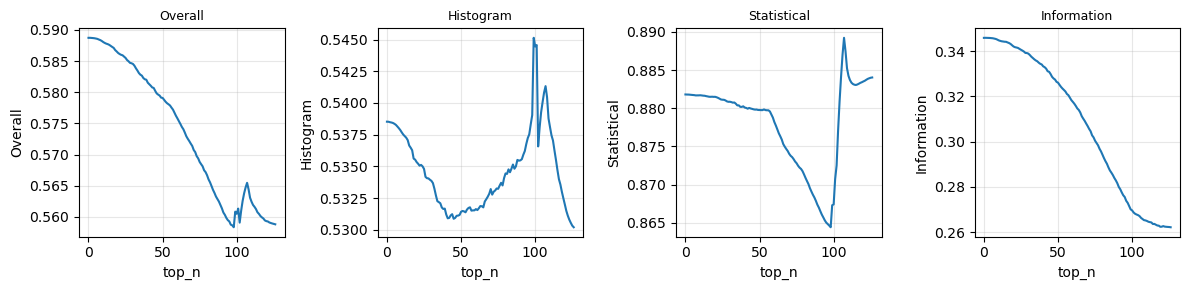

100%|██████████| 128/128 [00:10<00:00, 11.93it/s]


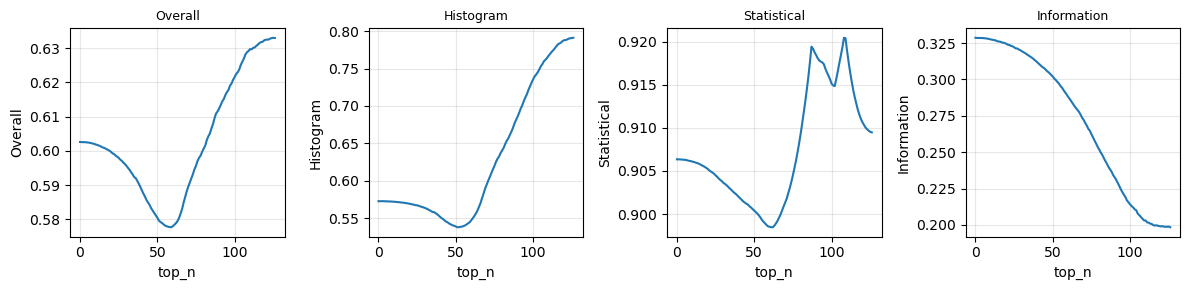

In [145]:
real_alpha = CImageAlpha(real_mean_list[51]).get_svd_alpha(count=128)
fake_alpha = CImageAlpha(fake_mean_list[51]).get_svd_alpha(count=128)
df_score = compaire_similar(real_alpha,fake_alpha)
df_score = compaire_similar(real_mean_list,fake_mean_list)

real_alpha = CImageAlpha(real_std_list[51]).get_svd_alpha(count=128)
fake_alpha = CImageAlpha(fake_std_list[51]).get_svd_alpha(count=128)
df_score = compaire_similar(real_alpha,fake_alpha)
df_score = compaire_similar(real_std_list,fake_std_list)

# MFS
1. R,G,B
2. A,D,F

100%|██████████| 128/128 [00:03<00:00, 39.77it/s]


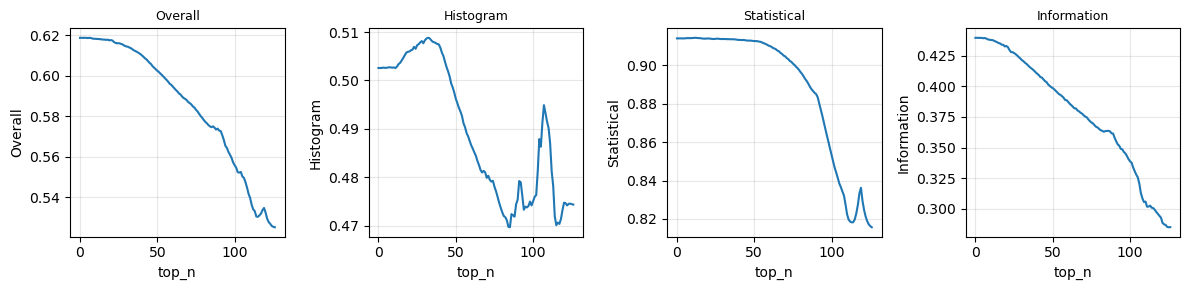

100%|██████████| 128/128 [00:03<00:00, 41.53it/s]


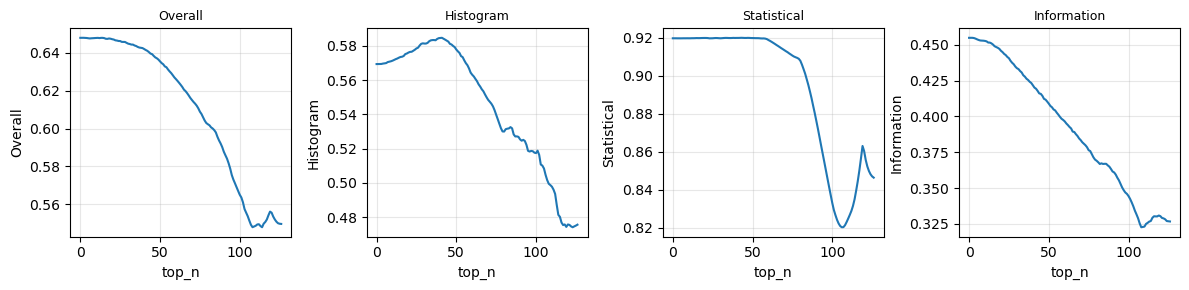

100%|██████████| 128/128 [00:03<00:00, 38.47it/s]


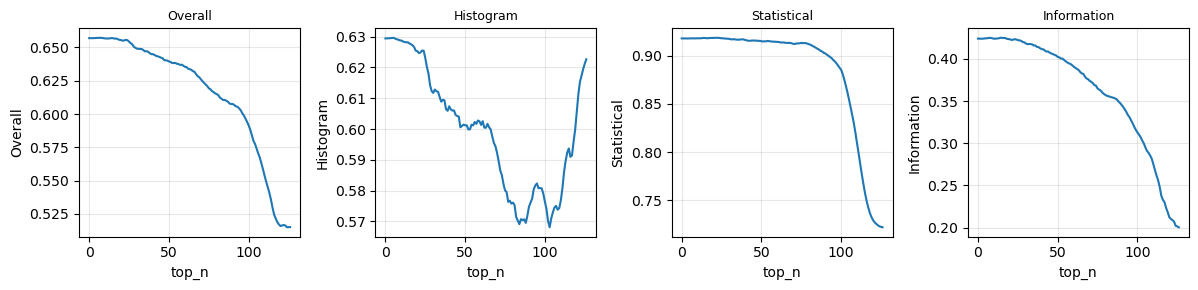

100%|██████████| 128/128 [00:11<00:00, 11.39it/s]


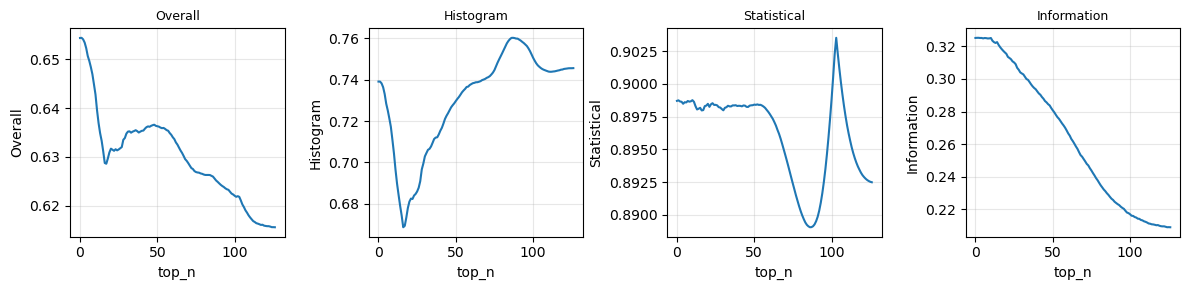

,Overall,Histogram,Statistical,Information,detail,top_n
0,0.654339,0.739060,0.898698,0.325260,"{'score': {'Overall': 0.65433947753142, 'Histo...",0
1,0.654375,0.739059,0.898736,0.325331,"{'score': {'Overall': 0.654375309147753, 'Hist...",1
2,0.654062,0.738194,0.898648,0.325343,"{'score': {'Overall': 0.6540620035025843, 'His...",2
3,0.653399,0.736338,0.898626,0.325233,"{'score': {'Overall': 0.6533989879292879, 'His...",3
4,0.652257,0.733055,0.898474,0.325241,"{'score': {'Overall': 0.652256525736592, 'Hist...",4
...,...,...,...,...,...,...
122,0.615829,0.745369,0.892760,0.209358,"{'score': {'Overall': 0.6158289250074082, 'His...",122
123,0.615746,0.745483,0.892660,0.209094,"{'score': {'Overall': 0.6157455413271931, 'His...",123
124,0.615629,0.745506,0.892583,0.208800,"{'score': {'Overall': 0.6156292429494115, 'His...",124
125,0.615627,0.745505,0.892525,0.208852,"{'score': {'Overall': 0.6156273002655888, 'His...",125


In [146]:
real_mfs_img = CImageMFS(real_mean_list[51],count = 128).get_image_mfs()
fake_mfs_img = CImageMFS(fake_mean_list[51],count = 128).get_image_mfs()

real_mfs_img_list = CImageDecompose(real_mfs_img[0]).get_svd_auto(count=128)
fake_mfs_img_list = CImageDecompose(fake_mfs_img[0]).get_svd_auto(count=128)
compaire_similar(real_mfs_img_list,fake_mfs_img_list)
real_mfs_img_list = CImageDecompose(real_mfs_img[1]).get_svd_auto(count=128)
fake_mfs_img_list = CImageDecompose(fake_mfs_img[1]).get_svd_auto(count=128)
compaire_similar(real_mfs_img_list,fake_mfs_img_list)
real_mfs_img_list = CImageDecompose(real_mfs_img[2]).get_svd_auto(count=128)
fake_mfs_img_list = CImageDecompose(fake_mfs_img[2]).get_svd_auto(count=128)
compaire_similar(real_mfs_img_list,fake_mfs_img_list)
compaire_similar(real_mean_list,fake_mean_list)

100%|██████████| 128/128 [00:03<00:00, 39.14it/s]


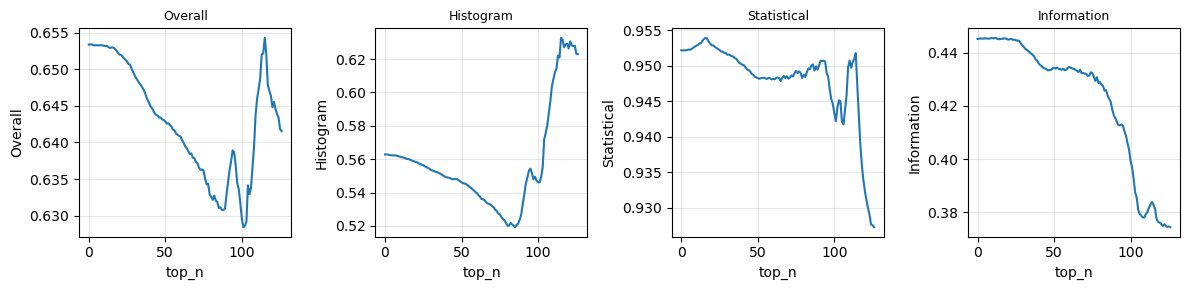

100%|██████████| 128/128 [00:02<00:00, 42.94it/s]


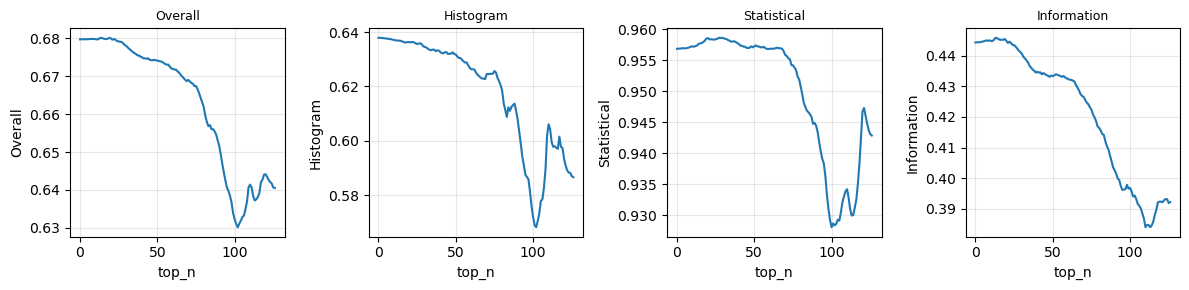

100%|██████████| 128/128 [00:02<00:00, 42.90it/s]


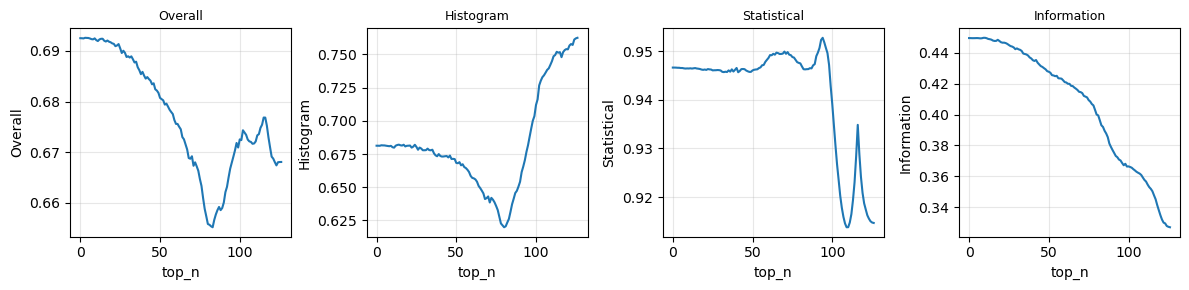

100%|██████████| 128/128 [00:10<00:00, 12.69it/s]


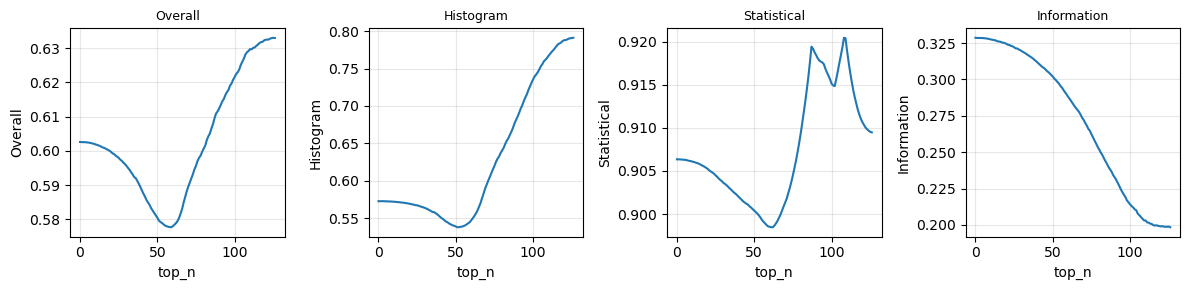

,Overall,Histogram,Statistical,Information,detail,top_n
0,0.602577,0.572808,0.906348,0.328573,"{'score': {'Overall': 0.6025765194974425, 'His...",0
1,0.602545,0.572797,0.906347,0.328491,"{'score': {'Overall': 0.6025450975274558, 'His...",1
2,0.602530,0.572803,0.906333,0.328454,"{'score': {'Overall': 0.6025299134550771, 'His...",2
3,0.602521,0.572804,0.906325,0.328435,"{'score': {'Overall': 0.6025214993668788, 'His...",3
4,0.602488,0.572723,0.906308,0.328432,"{'score': {'Overall': 0.6024876579923546, 'His...",4
...,...,...,...,...,...,...
122,0.632549,0.788893,0.910022,0.198730,"{'score': {'Overall': 0.6325486379479796, 'His...",122
123,0.632805,0.789832,0.909825,0.198757,"{'score': {'Overall': 0.6328047585178279, 'His...",123
124,0.632958,0.790502,0.909659,0.198714,"{'score': {'Overall': 0.632958248383804, 'Hist...",124
125,0.633033,0.790724,0.909535,0.198840,"{'score': {'Overall': 0.6330333038767028, 'His...",125


In [147]:
real_mfs_img = CImageMFS(real_std_list[51],count = 128).get_image_mfs()
fake_mfs_img = CImageMFS(fake_std_list[51],count = 128).get_image_mfs()

real_mfs_img_list = CImageDecompose(real_mfs_img[0]).get_svd_auto(count=128)
fake_mfs_img_list = CImageDecompose(fake_mfs_img[0]).get_svd_auto(count=128)
compaire_similar(real_mfs_img_list,fake_mfs_img_list)
real_mfs_img_list = CImageDecompose(real_mfs_img[1]).get_svd_auto(count=128)
fake_mfs_img_list = CImageDecompose(fake_mfs_img[1]).get_svd_auto(count=128)
compaire_similar(real_mfs_img_list,fake_mfs_img_list)
real_mfs_img_list = CImageDecompose(real_mfs_img[2]).get_svd_auto(count=128)
fake_mfs_img_list = CImageDecompose(fake_mfs_img[2]).get_svd_auto(count=128)
compaire_similar(real_mfs_img_list,fake_mfs_img_list)
compaire_similar(real_std_list,fake_std_list)

100%|██████████| 128/128 [00:02<00:00, 42.97it/s]


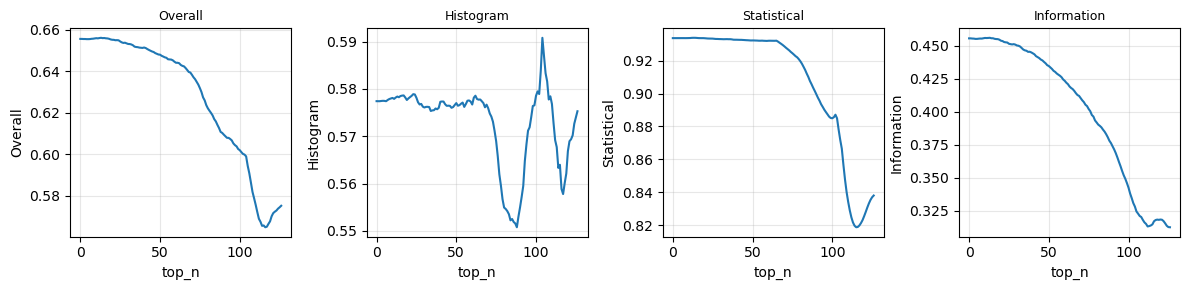

100%|██████████| 128/128 [00:03<00:00, 41.81it/s]


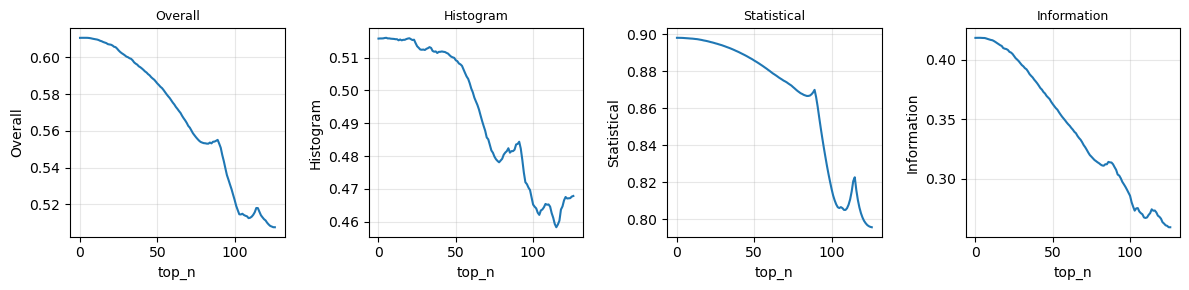

100%|██████████| 128/128 [00:03<00:00, 39.75it/s]


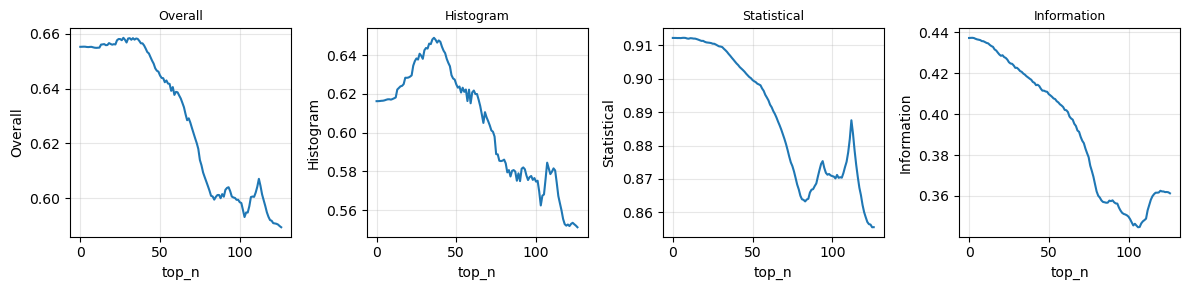

100%|██████████| 128/128 [00:10<00:00, 12.02it/s]


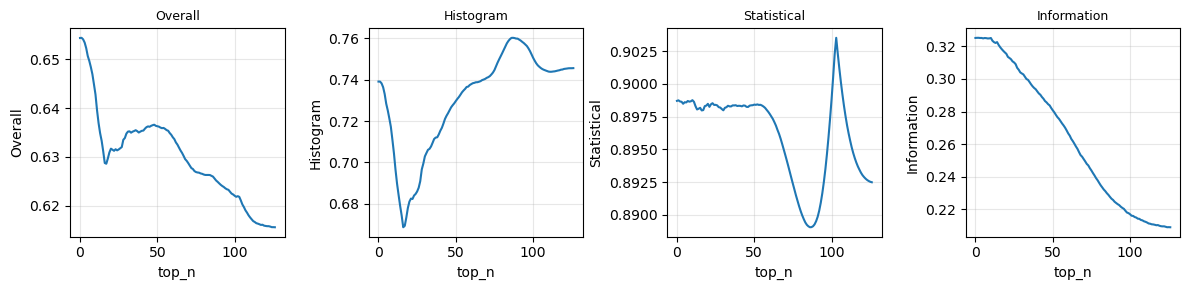

,Overall,Histogram,Statistical,Information,detail,top_n
0,0.654339,0.739060,0.898698,0.325260,"{'score': {'Overall': 0.65433947753142, 'Histo...",0
1,0.654375,0.739059,0.898736,0.325331,"{'score': {'Overall': 0.654375309147753, 'Hist...",1
2,0.654062,0.738194,0.898648,0.325343,"{'score': {'Overall': 0.6540620035025843, 'His...",2
3,0.653399,0.736338,0.898626,0.325233,"{'score': {'Overall': 0.6533989879292879, 'His...",3
4,0.652257,0.733055,0.898474,0.325241,"{'score': {'Overall': 0.652256525736592, 'Hist...",4
...,...,...,...,...,...,...
122,0.615829,0.745369,0.892760,0.209358,"{'score': {'Overall': 0.6158289250074082, 'His...",122
123,0.615746,0.745483,0.892660,0.209094,"{'score': {'Overall': 0.6157455413271931, 'His...",123
124,0.615629,0.745506,0.892583,0.208800,"{'score': {'Overall': 0.6156292429494115, 'His...",124
125,0.615627,0.745505,0.892525,0.208852,"{'score': {'Overall': 0.6156273002655888, 'His...",125


In [148]:
real_mfs_img = CImageMFS(real_mean_list[51],count = 128).get_mfs_image()
fake_mfs_img = CImageMFS(fake_mean_list[51],count = 128).get_mfs_image()
real_mfs_img_list = CImageDecompose(real_mfs_img[0]).get_svd_auto(count=128)
fake_mfs_img_list = CImageDecompose(fake_mfs_img[0]).get_svd_auto(count=128)
compaire_similar(real_mfs_img_list,fake_mfs_img_list)
real_mfs_img_list = CImageDecompose(real_mfs_img[1]).get_svd_auto(count=128)
fake_mfs_img_list = CImageDecompose(fake_mfs_img[1]).get_svd_auto(count=128)
compaire_similar(real_mfs_img_list,fake_mfs_img_list)
real_mfs_img_list = CImageDecompose(real_mfs_img[2]).get_svd_auto(count=128)
fake_mfs_img_list = CImageDecompose(fake_mfs_img[2]).get_svd_auto(count=128)
compaire_similar(real_mfs_img_list,fake_mfs_img_list)
compaire_similar(real_mean_list,fake_mean_list)

100%|██████████| 128/128 [00:02<00:00, 43.92it/s]


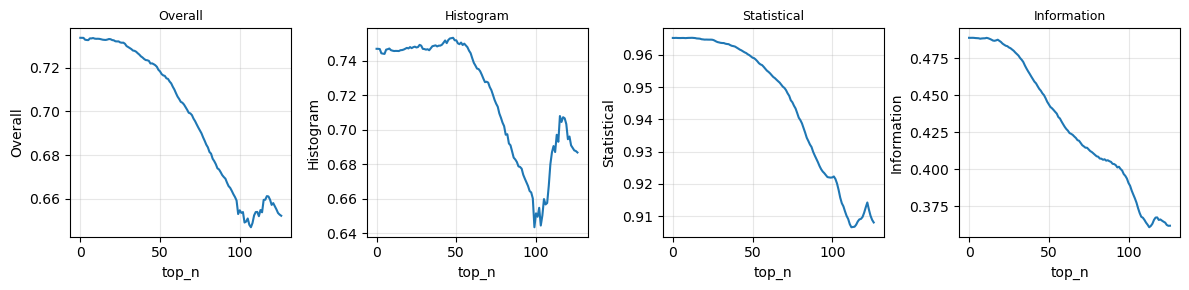

100%|██████████| 128/128 [00:04<00:00, 31.49it/s]


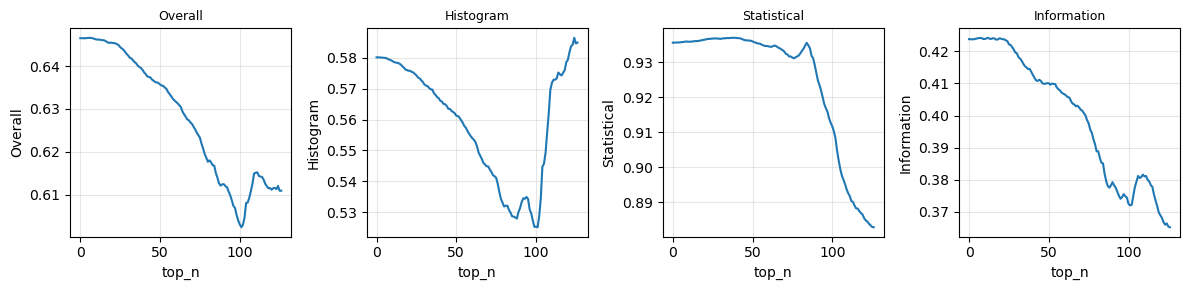

100%|██████████| 128/128 [00:03<00:00, 40.02it/s]


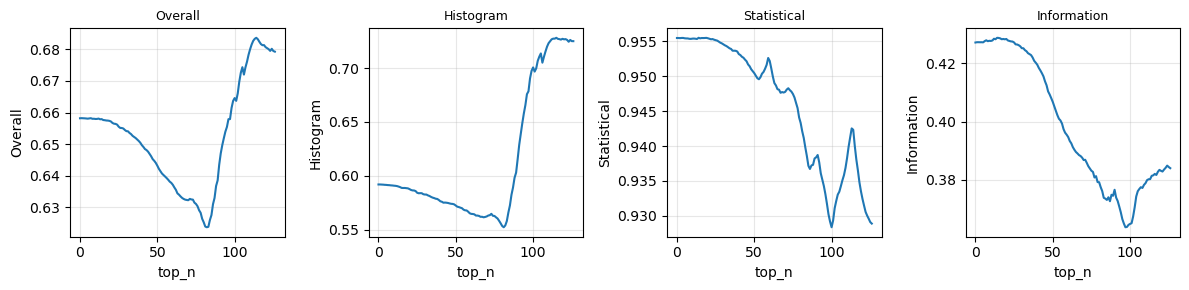

100%|██████████| 128/128 [00:11<00:00, 10.82it/s]


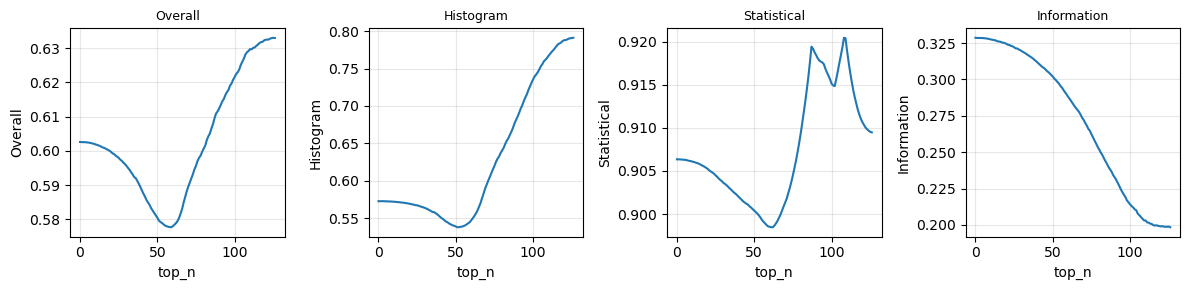

,Overall,Histogram,Statistical,Information,detail,top_n
0,0.602577,0.572808,0.906348,0.328573,"{'score': {'Overall': 0.6025765194974425, 'His...",0
1,0.602545,0.572797,0.906347,0.328491,"{'score': {'Overall': 0.6025450975274558, 'His...",1
2,0.602530,0.572803,0.906333,0.328454,"{'score': {'Overall': 0.6025299134550771, 'His...",2
3,0.602521,0.572804,0.906325,0.328435,"{'score': {'Overall': 0.6025214993668788, 'His...",3
4,0.602488,0.572723,0.906308,0.328432,"{'score': {'Overall': 0.6024876579923546, 'His...",4
...,...,...,...,...,...,...
122,0.632549,0.788893,0.910022,0.198730,"{'score': {'Overall': 0.6325486379479796, 'His...",122
123,0.632805,0.789832,0.909825,0.198757,"{'score': {'Overall': 0.6328047585178279, 'His...",123
124,0.632958,0.790502,0.909659,0.198714,"{'score': {'Overall': 0.632958248383804, 'Hist...",124
125,0.633033,0.790724,0.909535,0.198840,"{'score': {'Overall': 0.6330333038767028, 'His...",125


In [149]:
real_mfs_img = CImageMFS(real_std_list[51],count = 128).get_mfs_image()
fake_mfs_img = CImageMFS(fake_std_list[51],count = 128).get_mfs_image()
real_mfs_img_list = CImageDecompose(real_mfs_img[0]).get_svd_auto(count=128)
fake_mfs_img_list = CImageDecompose(fake_mfs_img[0]).get_svd_auto(count=128)
compaire_similar(real_mfs_img_list,fake_mfs_img_list)
real_mfs_img_list = CImageDecompose(real_mfs_img[1]).get_svd_auto(count=128)
fake_mfs_img_list = CImageDecompose(fake_mfs_img[1]).get_svd_auto(count=128)
compaire_similar(real_mfs_img_list,fake_mfs_img_list)
real_mfs_img_list = CImageDecompose(real_mfs_img[2]).get_svd_auto(count=128)
fake_mfs_img_list = CImageDecompose(fake_mfs_img[2]).get_svd_auto(count=128)
compaire_similar(real_mfs_img_list,fake_mfs_img_list)
compaire_similar(real_std_list,fake_std_list)